# Binary Classification Experiments

This notebook trains multiple Torchvision backbones for corn leaf infection classification. Each run uses batch size `128` and `50` epochs, then compares validation F1 scores and visualizes best/worst predictions for both classes with saliency maps.

## Imports

In [21]:
!rm -rf Corn-Infection-Detection

In [28]:
!pip install git+https://github.com/q-viper/Corn-Infection-Detection.git

  Cloning https://github.com/q-viper/Corn-Infection-Detection.git to /tmp/pip-req-build-akpr7l6p
  Running command git clone --filter=blob:none --quiet https://github.com/q-viper/Corn-Infection-Detection.git /tmp/pip-req-build-akpr7l6p
  Resolved https://github.com/q-viper/Corn-Infection-Detection.git to commit 493d4eae9948709b74a72f8de48b0cc75d5bd374
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for corn_vision: filename=corn_vision-0.1.0-py3-none-any.whl size=24675 sha256=b66496fb5aebf3f7a5343752f0a2cc37c2f7bf626bdbdba186da65f9058d02ee
  Stored in directory: /tmp/pip-ephem-wheel-cache-s73bwjgv/wheels/c8/cd/9d/2de90ca431d7bced33703968a3d0154fb1340204e16ae34d4d
Successfully built corn_vision
  Attempting uninstall: corn_vision
    Found existing installation: corn_vision 0.1.0
    Uninstalling corn_vision-0.1.0:
      Successfully uninstalled corn_vision-0.1.0


In [30]:
from datetime import datetime
from pathlib import Path
import csv
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# ROOT = Path.cwd() /'Corn-Infection-Detection/corn_vision'

# sys.path.insert(0, str(ROOT))

from corn_vision.core.configs import ClassificationDataSetConfig, ClassificationModelConfig, NNTrainerConfig
from corn_vision.core.defs import MetricType, OptimizerType, TorchVisionBackbone
from corn_vision.data.classification_dataset import CornClassificationDataset
from corn_vision.models.classification import TorchVisionBinaryClassifier
from corn_vision.trainers.classification import ClassificationTrainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [31]:
ROOT

PosixPath('/kaggle/working/Corn-Infection-Detection/corn_vision')

## Experiment Configuration

In [60]:
DATA_DIR = "/kaggle/input/datasets/qramkrishna/corn-leaf-infection-dataset/Corn Disease detection"
# DATA_DIR = ROOT / "assets" / "Corn Disease detection"
RESULT_DIR = ROOT / "results"

BATCH_SIZE = 128
EPOCHS = 10
IMAGE_SIZE = (224, 224)
MAX_DATA_PER_CLASS = -1
NUM_WORKERS = 0
TRAIN_BACKBONE = True
PRETRAINED = False
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PROGRESS_IMAGE_EVERY = 10
SAMPLE_IMAGE_COUNT = 12

BACKBONES = [
    TorchVisionBackbone.RESNET18,
    # TorchVisionBackbone.RESNET34,
    TorchVisionBackbone.EFFICIENTNET_B0,
    TorchVisionBackbone.MOBILENET_V3_LARGE,
    TorchVisionBackbone.CONVNEXT_TINY,
]

experiment_stamp = datetime.now().strftime("%Y%m%d")
print(f"Experiment: {experiment_stamp}")

Experiment: 20260708


## Helpers

In [61]:
def read_metrics_csv(metrics_path: Path) -> list[dict[str, float]]:
    rows = []
    with metrics_path.open("r", newline="", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            rows.append({key: float(value) for key, value in row.items()})
    return rows


def best_metric_row(rows: list[dict[str, float]], metric_name: str = "val_f1_score") -> dict[str, float]:
    return max(rows, key=lambda row: row[metric_name])


def tensor_to_rgb(image: torch.Tensor) -> np.ndarray:
    image = image.detach().cpu().clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


def saliency_overlay(rgb_image: np.ndarray, saliency: torch.Tensor, alpha: float = 0.45) -> np.ndarray:
    saliency_np = saliency.detach().cpu().numpy()
    saliency_np = (saliency_np - saliency_np.min()) / (saliency_np.max() - saliency_np.min() + 1e-8)
    heatmap = cv2.applyColorMap((saliency_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    return np.clip((1 - alpha) * rgb_image + alpha * heatmap, 0, 1)


def evaluate_model(model: TorchVisionBinaryClassifier, dataset: CornClassificationDataset, batch_size: int = 128):
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    model = model.to(device)
    model.eval()
    records = []
    offset = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1).cpu()
            predictions = probabilities.argmax(dim=1)
            for batch_idx in range(labels.shape[0]):
                true_label = int(labels[batch_idx].item())
                predicted_label = int(predictions[batch_idx].item())
                records.append(
                    {
                        "idx": offset + batch_idx,
                        "true": true_label,
                        "pred": predicted_label,
                        "prob_true": float(probabilities[batch_idx, true_label].item()),
                        "prob_pred": float(probabilities[batch_idx, predicted_label].item()),
                        "correct": true_label == predicted_label,
                    }
                )
            offset += labels.shape[0]
    return records


def select_best_worst_by_class(records: list[dict], class_ids=(0, 1)):
    selected = {}
    for class_id in class_ids:
        class_records = [record for record in records if record["true"] == class_id]
        if not class_records:
            continue
        correct_records = [record for record in class_records if record["correct"]]
        best_pool = correct_records if correct_records else class_records
        selected[(class_id, "best")] = max(best_pool, key=lambda record: record["prob_true"])
        selected[(class_id, "worst")] = min(class_records, key=lambda record: record["prob_true"])
    return selected


def load_model_for_run(summary: dict) -> TorchVisionBinaryClassifier:
    model_config = ClassificationModelConfig(
        backbone=summary["backbone"],
        pretrained=PRETRAINED,
        train_backbone=TRAIN_BACKBONE,
    )
    model = TorchVisionBinaryClassifier(config=model_config).to(device)
    state_dict = torch.load(summary["best_model_path"], map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

## Build Dataset Split

In [62]:
data_config = ClassificationDataSetConfig(
    image_dir=DATA_DIR,
    image_size=IMAGE_SIZE,
    max_data_per_class=MAX_DATA_PER_CLASS,
    train_ratio=0.8,
)
dataset = CornClassificationDataset(config=data_config)
train_dataset, val_dataset = dataset.get_datasets()
class_names = data_config.class_names
len(train_dataset), len(val_dataset), class_names

2026-07-08 12:51:56 | INFO     | corn_vision.data.classification_dataset:load_data:149 - Loaded classification samples from /kaggle/input/datasets/qramkrishna/corn-leaf-infection-dataset/Corn Disease detection: {'Healthy': 2000, 'Infected': 2225}
2026-07-08 12:51:56 | INFO     | corn_vision.data.classification_dataset:get_datasets:170 - Created classification split with 3380 train and 845 validation samples


(3380, 845, ('Healthy', 'Infected'))

## Train Backbones

In [ ]:
run_summaries = []

for backbone in BACKBONES:
    run_name = f"{backbone.value}_bs{BATCH_SIZE}_ep{EPOCHS}_{experiment_stamp}"
    print(f"\n=== Training {backbone.value} ===")

    model_config = ClassificationModelConfig(
        backbone=backbone,
        pretrained=PRETRAINED,
        train_backbone=TRAIN_BACKBONE,
    )
    trainer_config = NNTrainerConfig(
        result_dir=RESULT_DIR,
        expt_name="classification",
        run_name=run_name,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        optimizer=OptimizerType.ADAMW,
        device=str(device),
        number_of_workers=NUM_WORKERS,
        best_model_metric=MetricType.F1_SCORE,
        best_model_metric_greater=True,
        early_stopping_patience=EPOCHS,
        progress_image_every=PROGRESS_IMAGE_EVERY,
        progress_image_count=SAMPLE_IMAGE_COUNT,
        sample_image_count=SAMPLE_IMAGE_COUNT,
    )
    model = TorchVisionBinaryClassifier(config=model_config)
    trainer = ClassificationTrainer(
        config=trainer_config,
        model=model,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
    )
    best_model_path = Path(trainer.train())
    metrics = read_metrics_csv(trainer_config.run_dir / trainer_config.metric_file)
    best_row = best_metric_row(metrics)
    run_summaries.append(
        {
            "backbone": backbone,
            "run_name": run_name,
            "run_dir": trainer_config.run_dir,
            "best_model_path": best_model_path,
            "best_epoch": int(best_row["epoch"]),
            "best_val_f1": best_row["val_f1_score"],
            "best_val_accuracy": best_row["val_accuracy"],
        }
    )

run_summaries

2026-07-08 12:54:06 | INFO     | corn_vision.trainers.base:__init__:54 - Trainer initialized on device: cuda
2026-07-08 12:54:06 | INFO     | corn_vision.trainers.base:__init__:55 - Run directory: /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/resnet18_bs128_ep10_20260708
2026-07-08 12:54:06 | INFO     | corn_vision.trainers.base:__init__:56 - Training samples: 3380, validation samples: 845
2026-07-08 12:54:06 | INFO     | corn_vision.trainers.base:train:245 - Starting training



=== Training resnet18 ===


2026-07-08 12:54:08 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved train sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/resnet18_bs128_ep10_20260708/sample_images/train_samples.jpg
2026-07-08 12:54:10 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved validation sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/resnet18_bs128_ep10_20260708/sample_images/validation_samples.jpg
2026-07-08 12:54:10 | INFO     | corn_vision.trainers.base:train:252 - Epoch 1/10
Validation 1/10: 100%|██████████| 7/7 [01:45<00:00, 15.03s/batch, accuracy=0.4734, precision=0.0000, recall=0.0000, f1_score=0.0000, loss=3.1260]
2026-07-08 13:06:05 | INFO     | corn_vision.trainers.base:train:258 - Train metrics: accuracy=0.8340, precision=0.8399, recall=0.8461, f1_score=0.8430, loss=0.3490
2026-07-08 13:06:05 | INFO     | corn_vision.trainers.base:train:262 - Vali


=== Training efficientnet_b0 ===


2026-07-08 14:50:38 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved train sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/efficientnet_b0_bs128_ep10_20260708/sample_images/train_samples.jpg
2026-07-08 14:50:40 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved validation sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/efficientnet_b0_bs128_ep10_20260708/sample_images/validation_samples.jpg
2026-07-08 14:50:40 | INFO     | corn_vision.trainers.base:train:252 - Epoch 1/10
Validation 1/10: 100%|██████████| 7/7 [01:48<00:00, 15.46s/batch, accuracy=0.5266, precision=0.5266, recall=1.0000, f1_score=0.6899, loss=0.6946]
2026-07-08 15:01:58 | INFO     | corn_vision.trainers.base:train:258 - Train metrics: accuracy=0.5453, precision=0.5554, recall=0.6848, f1_score=0.6133, loss=0.6929
2026-07-08 15:01:58 | INFO     | corn_vision.trainers.base:tr


=== Training mobilenet_v3_large ===


2026-07-08 16:45:22 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved train sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/mobilenet_v3_large_bs128_ep10_20260708/sample_images/train_samples.jpg
2026-07-08 16:45:24 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved validation sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/mobilenet_v3_large_bs128_ep10_20260708/sample_images/validation_samples.jpg
2026-07-08 16:45:24 | INFO     | corn_vision.trainers.base:train:252 - Epoch 1/10
Validation 1/10: 100%|██████████| 7/7 [01:59<00:00, 17.03s/batch, accuracy=0.4734, precision=0.0000, recall=0.0000, f1_score=0.0000, loss=0.6932]
2026-07-08 17:01:18 | INFO     | corn_vision.trainers.base:train:258 - Train metrics: accuracy=0.5704, precision=0.5980, recall=0.5624, f1_score=0.5796, loss=0.6734
2026-07-08 17:01:18 | INFO     | corn_vision.trainers.b


=== Training convnext_tiny ===


2026-07-08 18:55:35 | INFO     | corn_vision.trainers.base:__init__:54 - Trainer initialized on device: cuda
2026-07-08 18:55:35 | INFO     | corn_vision.trainers.base:__init__:55 - Run directory: /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/convnext_tiny_bs128_ep10_20260708
2026-07-08 18:55:35 | INFO     | corn_vision.trainers.base:__init__:56 - Training samples: 3380, validation samples: 845
2026-07-08 18:55:35 | INFO     | corn_vision.trainers.base:train:245 - Starting training
2026-07-08 18:55:37 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved train sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/convnext_tiny_bs128_ep10_20260708/sample_images/train_samples.jpg
2026-07-08 18:55:39 | INFO     | corn_vision.trainers.classification:_log_sample_grid:59 - Saved validation sample image grid to /kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/convnext_tin

## Compare Best and Worst F1

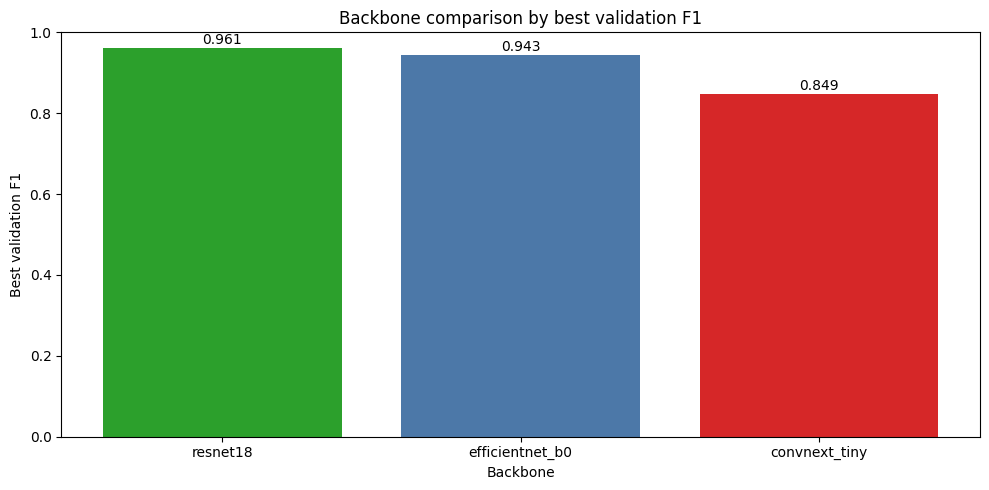

Best: {'backbone': <TorchVisionBackbone.RESNET18: 'resnet18'>, 'run_name': 'resnet18_bs128_ep10_20260708', 'run_dir': PosixPath('/kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/resnet18_bs128_ep10_20260708'), 'best_model_path': PosixPath('/kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/resnet18_bs128_ep10_20260708/best_model.pth'), 'best_epoch': 9, 'best_val_f1': 0.9609195402298851, 'best_val_accuracy': 0.9597633136094674}
Worst: {'backbone': <TorchVisionBackbone.MOBILENET_V3_LARGE: 'mobilenet_v3_large'>, 'run_name': 'mobilenet_v3_large_bs128_ep10_20260708', 'run_dir': PosixPath('/kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/mobilenet_v3_large_bs128_ep10_20260708'), 'best_model_path': PosixPath('/kaggle/working/Corn-Infection-Detection/corn_vision/results/classification/mobilenet_v3_large_bs128_ep10_20260708/best_model.pth'), 'best_epoch': 1, 'best_val_f1': 0.0, 'best_val_accuracy': 0.4733727810650887

In [74]:
best_summary = max(run_summaries, key=lambda item: item["best_val_f1"])
worst_summary = min(run_summaries, key=lambda item: item["best_val_f1"])



labels = [summary["backbone"].value for summary in run_summaries]
scores = [summary["best_val_f1"] for summary in run_summaries]

labels = [l for i,l in enumerate(labels) if scores[i]>0]
scores = [s for s in scores if s>0]

colors = ["#4C78A8"] * len(run_summaries)
colors[run_summaries.index(best_summary)] = "#2CA02C"
colors[run_summaries.index(worst_summary)] = "#D62728"

plt.figure(figsize=(10, 5))
plt.bar(labels, scores, color=colors)
plt.ylabel("Best validation F1")
plt.xlabel("Backbone")
plt.title("Backbone comparison by best validation F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
for idx, score in enumerate(scores):
    plt.text(idx, score + 0.01, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.savefig('clf_results.png')
plt.show()

print("Best:", best_summary)
print("Worst:", worst_summary)

## Best/Worst Predictions with Saliency Maps

This section uses the backbone with the best validation F1 and selects the best and worst validation examples for each class. The saliency maps are generated for the predicted class.

In [69]:
best_model = load_model_for_run(best_summary)
records = evaluate_model(best_model, val_dataset, batch_size=BATCH_SIZE)
selected_records = select_best_worst_by_class(records, class_ids=range(len(class_names)))
selected_records

{(0, 'best'): {'idx': 747,
  'true': 0,
  'pred': 0,
  'prob_true': 0.9999998807907104,
  'prob_pred': 0.9999998807907104,
  'correct': True},
 (0, 'worst'): {'idx': 266,
  'true': 0,
  'pred': 1,
  'prob_true': 0.0831814557313919,
  'prob_pred': 0.9168184995651245,
  'correct': False},
 (1, 'best'): {'idx': 676,
  'true': 1,
  'pred': 1,
  'prob_true': 0.9999971389770508,
  'prob_pred': 0.9999971389770508,
  'correct': True},
 (1, 'worst'): {'idx': 454,
  'true': 1,
  'pred': 0,
  'prob_true': 0.0002904650755226612,
  'prob_pred': 0.9997095465660095,
  'correct': False}}

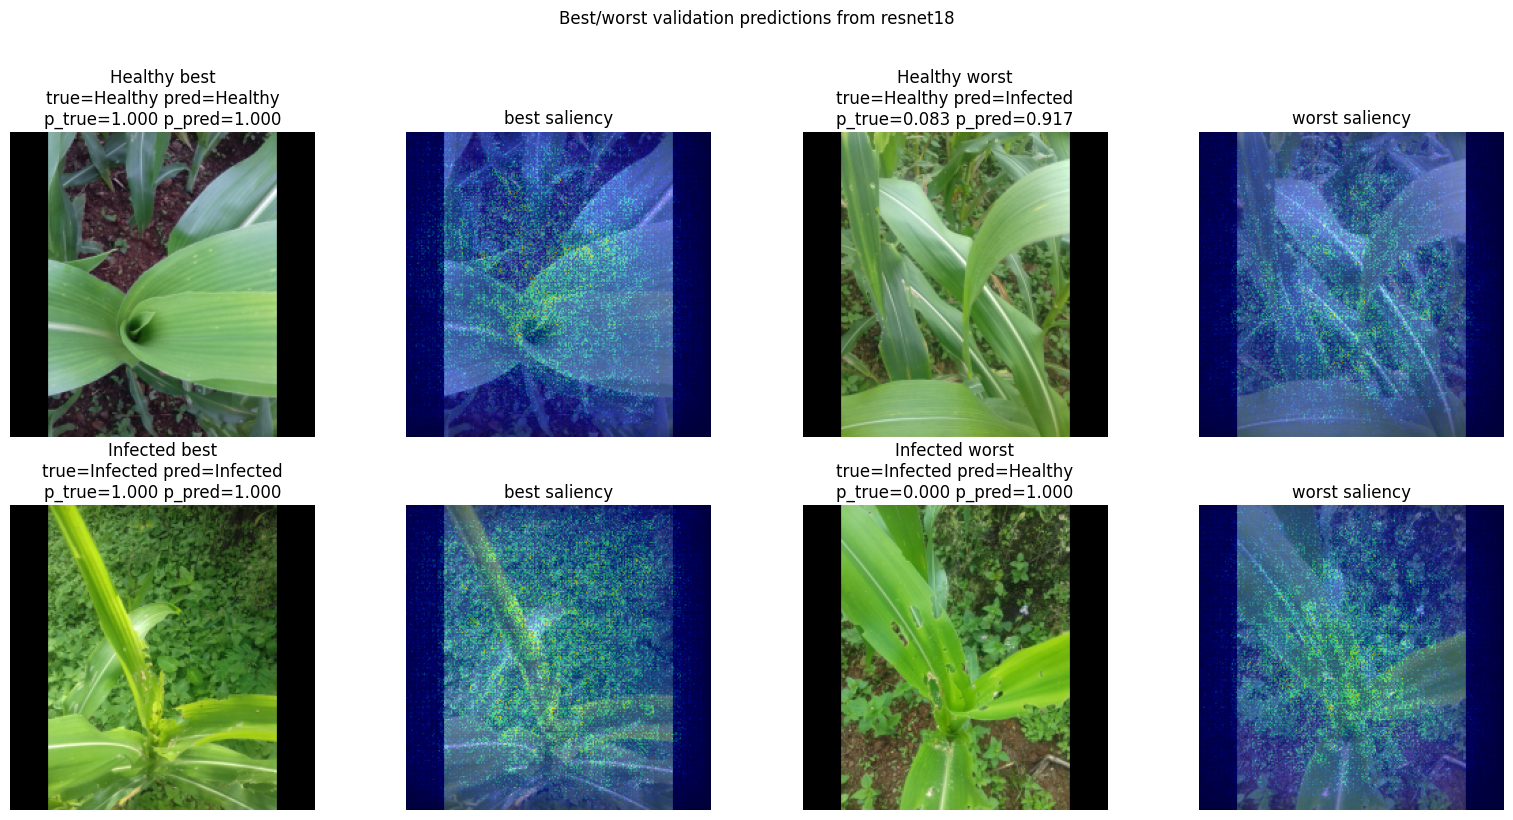

In [76]:
fig, axes = plt.subplots(len(class_names), 4, figsize=(16, 4 * len(class_names)))
if len(class_names) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, class_name in enumerate(class_names):
    for pair_idx, kind in enumerate(["best", "worst"]):
        record = selected_records.get((row_idx, kind))
        if record is None:
            continue
        image_tensor, _label = val_dataset[record["idx"]]
        input_tensor = image_tensor.unsqueeze(0).to(device)
        saliency = best_model.generate_saliency_map(
            input_tensor,
            target_class=record["pred"],
        )[0]
        rgb_image = tensor_to_rgb(image_tensor)
        overlay = saliency_overlay(rgb_image, saliency)

        image_ax = axes[row_idx, pair_idx * 2]
        saliency_ax = axes[row_idx, pair_idx * 2 + 1]
        image_ax.imshow(rgb_image)
        image_ax.set_title(
            f"{class_name} {kind}\n"
            f"true={class_names[record['true']]} pred={class_names[record['pred']]}\n"
            f"p_true={record['prob_true']:.3f} p_pred={record['prob_pred']:.3f}"
        )
        image_ax.axis("off")
        saliency_ax.imshow(overlay)
        saliency_ax.set_title(f"{kind} saliency")
        saliency_ax.axis("off")

plt.suptitle(f"Best/worst validation predictions from {best_summary['backbone'].value}", y=1.02)
plt.tight_layout()
plt.savefig('clf_smap.png')
plt.show()
